# UHPC

## Data Loading & Feature Isolation


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, LeaveOneGroupOut, GridSearchCV, GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from pipeline_w8 import preprocessing_pipeline
from sklearn.ensemble import HistGradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
import numpy as np
import matplotlib.pyplot as plt

# 50-feature dataset
df_drop = pd.read_csv(".//initial_data_preparation/Datasets/processed/uhpc_dataset/semantic_recoding_features_50.csv")

# 20-feature dataset
#df_drop = pd.read_csv(".//initial_data_preparation/Datasets/processed/uhpc_dataset/semantic_recoding_features_20.csv")

# Apply drops 
df_drop= df_drop.drop(columns=['cement_grade'])
fiber_cols = ['fiber1_length', 'fiber1_diameter']  
df_drop[fiber_cols] = df_drop[fiber_cols].fillna(0) 

groups = df_drop['publication']

# Proceed to split data
Y = df_drop['cs_28d'] 
X = df_drop.drop(columns=['cs_28d', 'publication'])


### Identify columns for encoding

In [2]:
# Identify all categorical columns
str_cols = X.select_dtypes(include=['object', 'str']).columns

# Sort text columns into One-Hot (<= 10 cat-s) and Target Encoding (> 10 cat-s)
one_hot_encode_cols = str_cols[X[str_cols].nunique() <= 10].tolist()
target_encode_cols = str_cols[X[str_cols].nunique() > 10].tolist()

# Identify all numeric columns
numeric_features = X.select_dtypes(include='number').columns.tolist()

# Print them out to verify
print(f"One-Hot columns: {len(one_hot_encode_cols)}")
print(f"Target Encoded columns: {len(target_encode_cols)}")
print(f"Numeric columns: {len(numeric_features)}")

One-Hot columns: 5
Target Encoded columns: 4
Numeric columns: 24


## Split: Train, Validation, Test

In [3]:
# 1st split: Separate Test (15%) from the rest (85%)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
trainval_idx, test_idx = next(gss1.split(X, Y, groups=groups))

X_trainval = X.iloc[trainval_idx]
Y_trainval = Y.iloc[trainval_idx]
groups_trainval = groups.iloc[trainval_idx]

X_test = X.iloc[test_idx]
Y_test = Y.iloc[test_idx]

# 2nd split: Separate Validation (15%) from Train (70%) 
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.18, random_state=42)
train_idx, val_idx = next(gss2.split(X_trainval, Y_trainval, groups=groups_trainval))

X_train = X_trainval.iloc[train_idx]
Y_train = Y_trainval.iloc[train_idx]

X_val = X_trainval.iloc[val_idx]
Y_val = Y_trainval.iloc[val_idx]

print(f"Train rows: {len(X_train)}")
print(f"Validation rows: {len(X_val)}")
print(f"Test rows: {len(X_test)}")
print(f"Total: {len(X_train) + len(X_val) + len(X_test)}")

Train rows: 1458
Validation rows: 331
Test rows: 283
Total: 2072


## Applying GridSearchCV 

In [4]:
# Define the base models
models = {
    'XGBoost': XGBRegressor(random_state=42),
    'HistGradient': HistGradientBoostingRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42)
}

# Define the parameter grids. 
param_grids = {
    'XGBoost': {
        'model__n_estimators': [50, 100, 200, 500],
        'model__max_depth': [3, 5, 10, 15],
        'model__learning_rate': [0.05, 0.1, 0.2]
    },
    'HistGradient': {
        'model__max_iter': [50, 100, 200, 500],
        'model__max_depth': [3, 5, 10, 15],
        'model__learning_rate': [0.05, 0.1, 0.2]
    },
    'AdaBoost': {
        'model__n_estimators': [50, 100, 200, 500],
        'model__learning_rate': [0.05, 0.1, 0.2]
    }
}

best_pipelines = {}
tuning_results = []

for name, model in models.items():
    
    # Build your custom pipeline
    pipe = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, estimator=model)
    
    # Run GridSearch, using scoring MAE
    gs = GridSearchCV(pipe, param_grids[name], cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    gs.fit(X_train, Y_train)
    
    # Save the best pipeline
    best_pipelines[name] = gs.best_estimator_
    
    # Evaluate it on the Validation
    val_Y_pred = gs.best_estimator_.predict(X_val)
    val_r2 = r2_score(Y_val, val_Y_pred)
    val_rmse = root_mean_squared_error(Y_val, val_Y_pred)
    val_mae = mean_absolute_error(Y_val, val_Y_pred)
    
    tuning_results.append({
        'Model': name,
        'Best Params': gs.best_params_,
        'Val R2': val_r2,
        'Val MAE': val_mae,
        'Val RMSE': val_rmse
    })

tuning_df = pd.DataFrame(tuning_results)[['Model', 'Val R2', 'Val MAE', 'Val RMSE', 'Best Params']]

# Remove the column width limit
pd.set_option('display.max_colwidth', None)
display(tuning_df)

,Model,Val R2,Val MAE,Val RMSE,Best Params
0,XGBoost,0.373188,28.445171,38.936748,"{'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 50}"
1,HistGradient,0.399755,29.058639,38.102651,"{'model__learning_rate': 0.2, 'model__max_depth': 15, 'model__max_iter': 50}"
2,AdaBoost,0.359108,29.179042,39.371625,"{'model__learning_rate': 0.1, 'model__n_estimators': 500}"


### Check the total final columns after preprocessing 

In [5]:
# Extract the XGBoost pipeline
preprocessor_check = best_pipelines['XGBoost'].named_steps['preprocessor']

# Get the final column names after One-Hot Encoding
final_columns = preprocessor_check.get_feature_names_out()

print(f"Total columns after all encodings: {len(final_columns)}")

# To print column names
print(final_columns)

Total columns after all encodings: 60
['num__cement' 'num__silica_fume' 'num__fly_ash' 'num__limestone_powder'
 'num__quartz_powder' 'num__glass_powder' 'num__rice_husk_ash'
 'num__metakaolin' 'num__ggbfs' 'num__slag' 'num__nano_caco3'
 'num__nano_al2o3' 'num__nano_tio2' 'num__nano_sio2' 'num__filler'
 'num__sand' 'num__sand_max_size' 'num__fiber1_amount'
 'num__fiber1_length' 'num__fiber1_diameter' 'num__fiber2_amount'
 'num__water' 'num__sp_amount' 'num__curing_temp'
 'ohe__fly_ash_type_class C' 'ohe__fly_ash_type_class F'
 'ohe__fly_ash_type_not_applicable' 'ohe__fly_ash_type_unknown_type'
 'ohe__slag_type_Copper Slag' 'ohe__slag_type_Phosphorous Slag'
 'ohe__slag_type_Steel Slag' 'ohe__slag_type_Steel Slag \r\nPowder'
 'ohe__slag_type_not_applicable' 'ohe__slag_type_unknown_type'
 'ohe__fiber2_type_Carbon Fiber' 'ohe__fiber2_type_Cellulose Fiber'
 'ohe__fiber2_type_Hooked Steel Fiber' 'ohe__fiber2_type_PE Fiber'
 'ohe__fiber2_type_PVA Fiber' 'ohe__fiber2_type_Straight Steel Fiber'


### Leave one publication group out + Quantile Boosting 


In [6]:
# Initialize ALL tracking lists
publications = []
Y_true_all = []

# HistGradient tracking
Y_pred_all_hist = []
Y_lower_all_hist = []
Y_upper_all_hist = []

# XGBoost tracking
Y_pred_all_xgb = []
Y_lower_all_xgb = []
Y_upper_all_xgb = []

# Find publications with >= 50 rows
pub_counts = groups.value_counts()
eligible_pubs = pub_counts[pub_counts >= 50].index.tolist()
print(f"Eligible publications (>=50 rows): {eligible_pubs}")

lopo_results = []

# Leave-One-Out Loop
for publ_name in eligible_pubs:
    
    # Create masks to isolate the specific publication
    test_mask = groups == publ_name
    train_mask = groups != publ_name
    X_train_lopo = X[train_mask]
    X_test_lopo = X[test_mask]
    Y_train_lopo = Y[train_mask]
    Y_test_lopo = Y[test_mask]

    # Get the publication groups for the training data
    groups_train_lopo = groups[train_mask]

    # Create a validation set from the remaining training data
    gss_lopo = GroupShuffleSplit(n_splits=1, test_size=0.18, random_state=42)
    train_idx, val_idx = next(gss_lopo.split(X_train_lopo, Y_train_lopo, groups=groups_train_lopo))
    
    # Final data for this loop
    X_train_lopo_fin = X_train_lopo.iloc[train_idx]
    Y_train_lopo_fin = Y_train_lopo.iloc[train_idx]
    X_val_lopo = X_train_lopo.iloc[val_idx]
    Y_val_lopo = Y_train_lopo.iloc[val_idx]
    
    # Predict using best pipelines
    for name, pipe in best_pipelines.items():
        
        # Fit the best tuned pipeline on the training data
        pipe.fit(X_train_lopo_fin, Y_train_lopo_fin)
        Y_pred_val = pipe.predict(X_val_lopo)
        Y_pred_test = pipe.predict(X_test_lopo)
        r2 = r2_score(Y_test_lopo, Y_pred_test)
        rmse = root_mean_squared_error(Y_test_lopo, Y_pred_test)
        mae = mean_absolute_error(Y_test_lopo, Y_pred_test)
        
        residuals = Y_val_lopo.values - Y_pred_val
        mean_residual = np.mean(residuals)
        direction = "Over-predicting" if mean_residual < 0 else "Under-predicting"
        worst_error = np.max(np.abs(residuals))
        
        # Conformal interval
        # Compute percentile for the current split
        perc = np.percentile(np.abs(residuals), 90)

        # Identify lower and upper bounds 
        Y_pred_test_lower = Y_pred_test - perc
        Y_pred_test_upper = Y_pred_test + perc
        
        # Evaluate coverage of true values with the interval
        coverage_mask_90 =  (Y_pred_test_lower <= Y_test_lopo) & (Y_test_lopo <= Y_pred_test_upper)
        coverage = np.mean(coverage_mask_90)*100

        lopo_results.append({
            'Publication': publ_name,
            'Model': name,
            'Rows': test_mask.sum(),
            'R2': r2,
            'MAE': mae,
            'RMSE': rmse,
            'Direction': direction,
            'Mean_residual': mean_residual,
            'Worst_Error_MPa': round(worst_error, 2),
            'Conformal_Coverage_%': coverage
        })

        if name == 'HistGradient':
            # Track predictions
            publications.extend([publ_name] * len(Y_test_lopo))
            Y_true_all.extend(Y_test_lopo.tolist())
            Y_pred_all_hist.extend(Y_pred_test.tolist())

            # Generate and track quantile boundaries
            best_params_hist = pipe.named_steps['model'].get_params()
            best_params_hist.pop('loss', None)
            best_params_hist.pop('quantile', None)

            pipe_lower_hist = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, 
                                                estimator=HistGradientBoostingRegressor(loss='quantile', quantile=0.05, **best_params_hist))
            pipe_upper_hist = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, 
                                                estimator=HistGradientBoostingRegressor(loss='quantile', quantile=0.95, **best_params_hist))
            
            pipe_lower_hist.fit(X_train_lopo_fin, Y_train_lopo_fin)
            pipe_upper_hist.fit(X_train_lopo_fin, Y_train_lopo_fin)
            
            Y_lower_all_hist.extend(pipe_lower_hist.predict(X_test_lopo).tolist())
            Y_upper_all_hist.extend(pipe_upper_hist.predict(X_test_lopo).tolist())

        elif name == 'XGBoost':
            # Track predictions
            Y_pred_all_xgb.extend(Y_pred_test.tolist())

            # Generate and track quantile boundaries
            best_params_xgb = pipe.named_steps['model'].get_params()
            
            # Pop 2 parameters then assing then in pipeline call
            best_params_xgb.pop('objective', None)
            best_params_xgb.pop('quantile_alpha', None)

            pipe_lower_xgb = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, 
                                                estimator=XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.05, **best_params_xgb))
            pipe_upper_xgb = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, 
                                                estimator=XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.95, **best_params_xgb))
            
            pipe_lower_xgb.fit(X_train_lopo_fin, Y_train_lopo_fin)
            pipe_upper_xgb.fit(X_train_lopo_fin, Y_train_lopo_fin)
            
            Y_lower_all_xgb.extend(pipe_lower_xgb.predict(X_test_lopo).tolist())
            Y_upper_all_xgb.extend(pipe_upper_xgb.predict(X_test_lopo).tolist())

lopo_df = pd.DataFrame(lopo_results)
display(lopo_df)


Eligible publications (>=50 rows): ['Ref-144-Research', 'Ref-121-Research', 'Ref-141-Research', 'Ref-48-Research', 'Ref-85-Research', 'Ref-139-Research']


,Publication,Model,Rows,R2,MAE,RMSE,Direction,Mean_residual,Worst_Error_MPa,Conformal_Coverage_%
0,Ref-144-Research,XGBoost,112,0.535335,16.135933,20.403158,Over-predicting,-4.035136,55.02,90.178571
1,Ref-144-Research,HistGradient,112,0.555491,16.362178,19.955728,Over-predicting,-2.635776,74.07,92.857143
2,Ref-144-Research,AdaBoost,112,0.318365,19.163052,24.711730,Over-predicting,-4.196588,65.14,87.500000
3,Ref-121-Research,XGBoost,80,0.510801,16.576217,20.331813,Over-predicting,-6.810382,61.13,96.250000
4,Ref-121-Research,HistGradient,80,0.435222,18.090336,21.846005,Over-predicting,-8.434516,75.28,95.000000
5,Ref-121-Research,AdaBoost,80,0.075728,23.018959,27.946878,Over-predicting,-8.181252,70.47,87.500000
6,Ref-141-Research,XGBoost,73,-1.012005,13.780686,17.711607,Over-predicting,-5.251678,82.50,94.520548
7,Ref-141-Research,HistGradient,73,0.259536,8.971503,10.744725,Over-predicting,-4.213486,72.61,100.000000
8,Ref-141-Research,AdaBoost,73,-0.171836,11.426341,13.516890,Over-predicting,-6.113913,66.25,100.000000
9,Ref-48-Research,XGBoost,72,0.065521,22.666022,27.337455,Over-predicting,-3.423611,68.71,81.944444


Publications 48 and 85 are the worst performers in terms of MAE and RMSE.
 
Comparing the MAE and Mean Residual shows that the error is not systematic, implying that outliers significantly influence the predictions.

### Average LOPO

In [7]:
lopo_avg = lopo_df.groupby('Model')[['MAE', 'RMSE', 'R2', 'Conformal_Coverage_%']].mean()
display(lopo_avg)

,MAE,RMSE,R2,Conformal_Coverage_%
Model,,,,
AdaBoost,21.410009,26.402335,-0.189523,84.555419
HistGradient,18.506214,22.749753,0.103914,88.533108
XGBoost,18.989892,24.134398,-0.103046,86.518821


## Calibration table

### Calibration + Coverage Analysis 


In [8]:
df_results = pd.DataFrame({
    'Publication': publications,
    'Y_true': Y_true_all,
    'Hist_Pred': Y_pred_all_hist,
    'Hist_Lower': Y_lower_all_hist,
    'Hist_Upper': Y_upper_all_hist,
    'XGB_Pred': Y_pred_all_xgb,
    'XGB_Lower': Y_lower_all_xgb,
    'XGB_Upper': Y_upper_all_xgb
})

# Calculate widths and coverage
df_results['Hist_Width'] = df_results['Hist_Upper'] - df_results['Hist_Lower']
df_results['Hist_Covered'] = (df_results['Hist_Lower'] <= df_results['Y_true']) & (df_results['Y_true'] <= df_results['Hist_Upper'])

df_results['XGB_Width'] = df_results['XGB_Upper'] - df_results['XGB_Lower']
df_results['XGB_Covered'] = (df_results['XGB_Lower'] <= df_results['Y_true']) & (df_results['Y_true'] <= df_results['XGB_Upper'])

# Group by publication to create the Calibration table
calibration_table = df_results.groupby('Publication').agg(
    Avg_True_Strength=('Y_true', 'mean'),
    Hist_Avg_Width=('Hist_Width', 'mean'),
    Hist_Coverage=('Hist_Covered', lambda x: np.mean(x) * 100),
    XGB_Avg_Width=('XGB_Width', 'mean'),
    XGB_Coverage=('XGB_Covered', lambda x: np.mean(x) * 100)
).reset_index()

def label_confidence(coverage_pct):
    if coverage_pct < 85.0:
        return 'Overconfident'
    elif coverage_pct > 95.0:
        return 'Underconfident'
    else:
        return 'Well-Calibrated'

# Apply the labels to both models
calibration_table['Hist_Status'] = calibration_table['Hist_Coverage'].apply(label_confidence)
calibration_table['XGB_Status'] = calibration_table['XGB_Coverage'].apply(label_confidence)

display(calibration_table)

,Publication,Avg_True_Strength,Hist_Avg_Width,Hist_Coverage,XGB_Avg_Width,XGB_Coverage,Hist_Status,XGB_Status
0,Ref-121-Research,165.075000,58.968666,68.750000,87.161629,95.000000,Overconfident,Well-Calibrated
1,Ref-139-Research,134.101961,47.817435,72.549020,65.114313,90.196078,Overconfident,Well-Calibrated
2,Ref-141-Research,132.506849,31.989691,87.671233,64.824589,95.890411,Well-Calibrated,Underconfident
3,Ref-144-Research,157.053571,53.357186,75.892857,74.815947,83.928571,Overconfident,Overconfident
4,Ref-48-Research,188.104167,53.804944,38.888889,70.074285,54.166667,Overconfident,Overconfident
5,Ref-85-Research,173.250000,48.335343,54.687500,65.205012,54.687500,Overconfident,Overconfident


Publications 48 and 85 have poor coverage 

Coverage of 48 with HistGrad is 33% meaning 67% actual values outside the interval.

Publ. 121 has the largest interval width 87 MPa

### Plotting


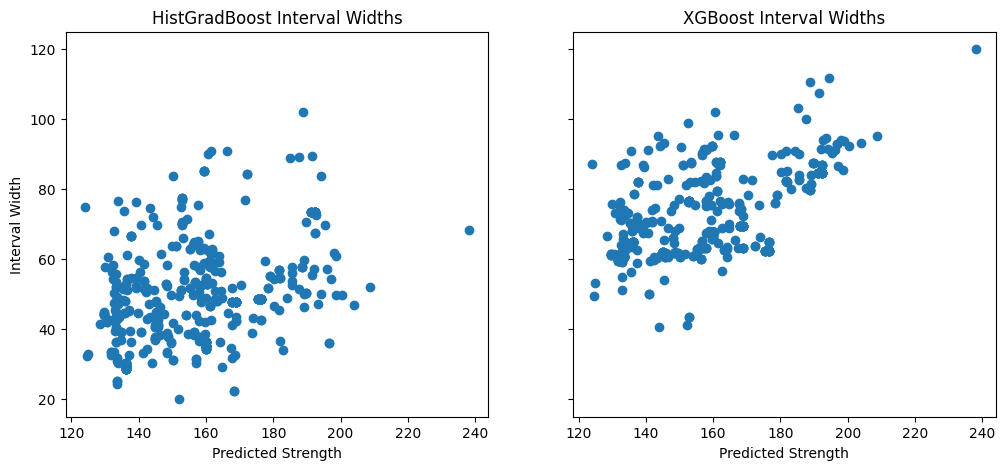

In [9]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(12, 5))

# Plot HistGradient
axs[0].scatter(df_results['XGB_Pred'], df_results['Hist_Width'])
axs[0].set_title('HistGradBoost Interval Widths')
axs[0].set_xlabel('Predicted Strength')
axs[0].set_ylabel('Interval Width')

# Plot XGBoost
axs[1].scatter(df_results['XGB_Pred'], df_results['XGB_Width'])
axs[1].set_title('XGBoost Interval Widths')
axs[1].set_xlabel('Predicted Strength')

plt.show()

XGBoost expands its prediction intervals for extreme recipes. 

HistGradient failed to scale its uncertainty for extreme predictions, resulting in severe overconfidence.

### Shared Publication Split vs LOPO Comparison


In [10]:
# XGBoost shared split
best_params_xgb = best_pipelines['XGBoost'].named_steps['model'].get_params()
best_params_xgb.pop('objective', None)
best_params_xgb.pop('quantile_alpha', None)

pipe_lower_xgb_shared = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, 
                                        estimator=XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.05, **best_params_xgb))
pipe_upper_xgb_shared = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, 
                                        estimator=XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.95, **best_params_xgb))

# Train on the standard random Train set, predict on the random Test set
pipe_lower_xgb_shared.fit(X_train, Y_train)
pipe_upper_xgb_shared.fit(X_train, Y_train)

Y_lower_xgb_shared = pipe_lower_xgb_shared.predict(X_test)
Y_upper_xgb_shared = pipe_upper_xgb_shared.predict(X_test)

# Calculate width and coverage
xgb_width_shared = np.mean(Y_upper_xgb_shared - Y_lower_xgb_shared)
xgb_covered_shared = np.mean((Y_lower_xgb_shared <= Y_test) & (Y_test <= Y_upper_xgb_shared)) * 100


# HistGradient shared split
best_params_hist = best_pipelines['HistGradient'].named_steps['model'].get_params()
best_params_hist.pop('loss', None)
best_params_hist.pop('quantile', None)

pipe_lower_hist_shared = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, 
                                        estimator=HistGradientBoostingRegressor(loss='quantile', quantile=0.05, **best_params_hist))
pipe_upper_hist_shared = preprocessing_pipeline(one_hot_encode_cols, target_encode_cols, numeric_features, 
                                        estimator=HistGradientBoostingRegressor(loss='quantile', quantile=0.95, **best_params_hist))

pipe_lower_hist_shared.fit(X_train, Y_train)
pipe_upper_hist_shared.fit(X_train, Y_train)

Y_lower_hist_shared = pipe_lower_hist_shared.predict(X_test)
Y_upper_hist_shared = pipe_upper_hist_shared.predict(X_test)

hist_width_shared = np.mean(Y_upper_hist_shared - Y_lower_hist_shared)
hist_covered_shared = np.mean((Y_lower_hist_shared <= Y_test) & (Y_test <= Y_upper_hist_shared)) * 100



### Publication-held-out (group split)

In [11]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, test_idx = next(gss.split(X, Y, groups=groups))

X_train_group = X.iloc[train_idx]
Y_train_group = Y.iloc[train_idx]
X_test_group = X.iloc[test_idx]
Y_test_group = Y.iloc[test_idx]

pipe_lower_xgb_shared.fit(X_train_group, Y_train_group)
pipe_upper_xgb_shared.fit(X_train_group, Y_train_group)

Y_lower_xgb_group = pipe_lower_xgb_shared.predict(X_test_group)
Y_upper_xgb_group = pipe_upper_xgb_shared.predict(X_test_group)

xgb_width_group = np.mean(Y_upper_xgb_group - Y_lower_xgb_group)
xgb_covered_group = np.mean((Y_lower_xgb_group <= Y_test_group) & (Y_test_group <= Y_upper_xgb_group)) * 100

pipe_lower_hist_shared.fit(X_train_group, Y_train_group)
pipe_upper_hist_shared.fit(X_train_group, Y_train_group)

Y_lower_hist_group = pipe_lower_hist_shared.predict(X_test_group)
Y_upper_hist_group = pipe_upper_hist_shared.predict(X_test_group)

hist_width_group = np.mean(Y_upper_hist_group - Y_lower_hist_group)
hist_covered_group = np.mean((Y_lower_hist_group <= Y_test_group) & (Y_test_group <= Y_upper_hist_group)) * 100

### Comparison table

In [12]:
# Display the 3-Way Comparison
comparison_df = pd.DataFrame({
    'Evaluation Method': [
        '1. Shared Split (Random Rows)', 
        '2. Publication Held-Out (Group Split)', 
        '3. LOPO (Exhaustive Unseen Labs)'
    ],
    'XGBoost Coverage %': [xgb_covered_shared, xgb_covered_group, calibration_table['XGB_Coverage'].mean()],
    'XGBoost Avg Width MPa': [xgb_width_shared, xgb_width_group, calibration_table['XGB_Avg_Width'].mean()],
    'HistGrad Coverage %': [hist_covered_shared, hist_covered_group, calibration_table['Hist_Coverage'].mean()],
    'HistGrad Avg Width MPa': [hist_width_shared, hist_width_group, calibration_table['Hist_Avg_Width'].mean()]
})

display(comparison_df.round(2))

,Evaluation Method,XGBoost Coverage %,XGBoost Avg Width MPa,HistGrad Coverage %,HistGrad Avg Width MPa
0,1. Shared Split (Random Rows),88.69,75.08,70.32,48.42
1,2. Publication Held-Out (Group Split),88.69,70.13,78.45,49.53
2,3. LOPO (Exhaustive Unseen Labs),78.98,71.20,66.41,49.05


### Apply SHAP (SHapley Additive exPlanations) investigating overconfident failures

d:\Studium\sem3\Project\Da2De\Da2De\S4_Boosting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP Analysis for the max error publication Ref-85-Research
True Concrete Strength:      232.00 MPa
XGBoost Predicted Strength:  158.30 MPa
Absolute Error:              73.70 MPa


) missing from font(s) DejaVu Sans.\S4_Boosting\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


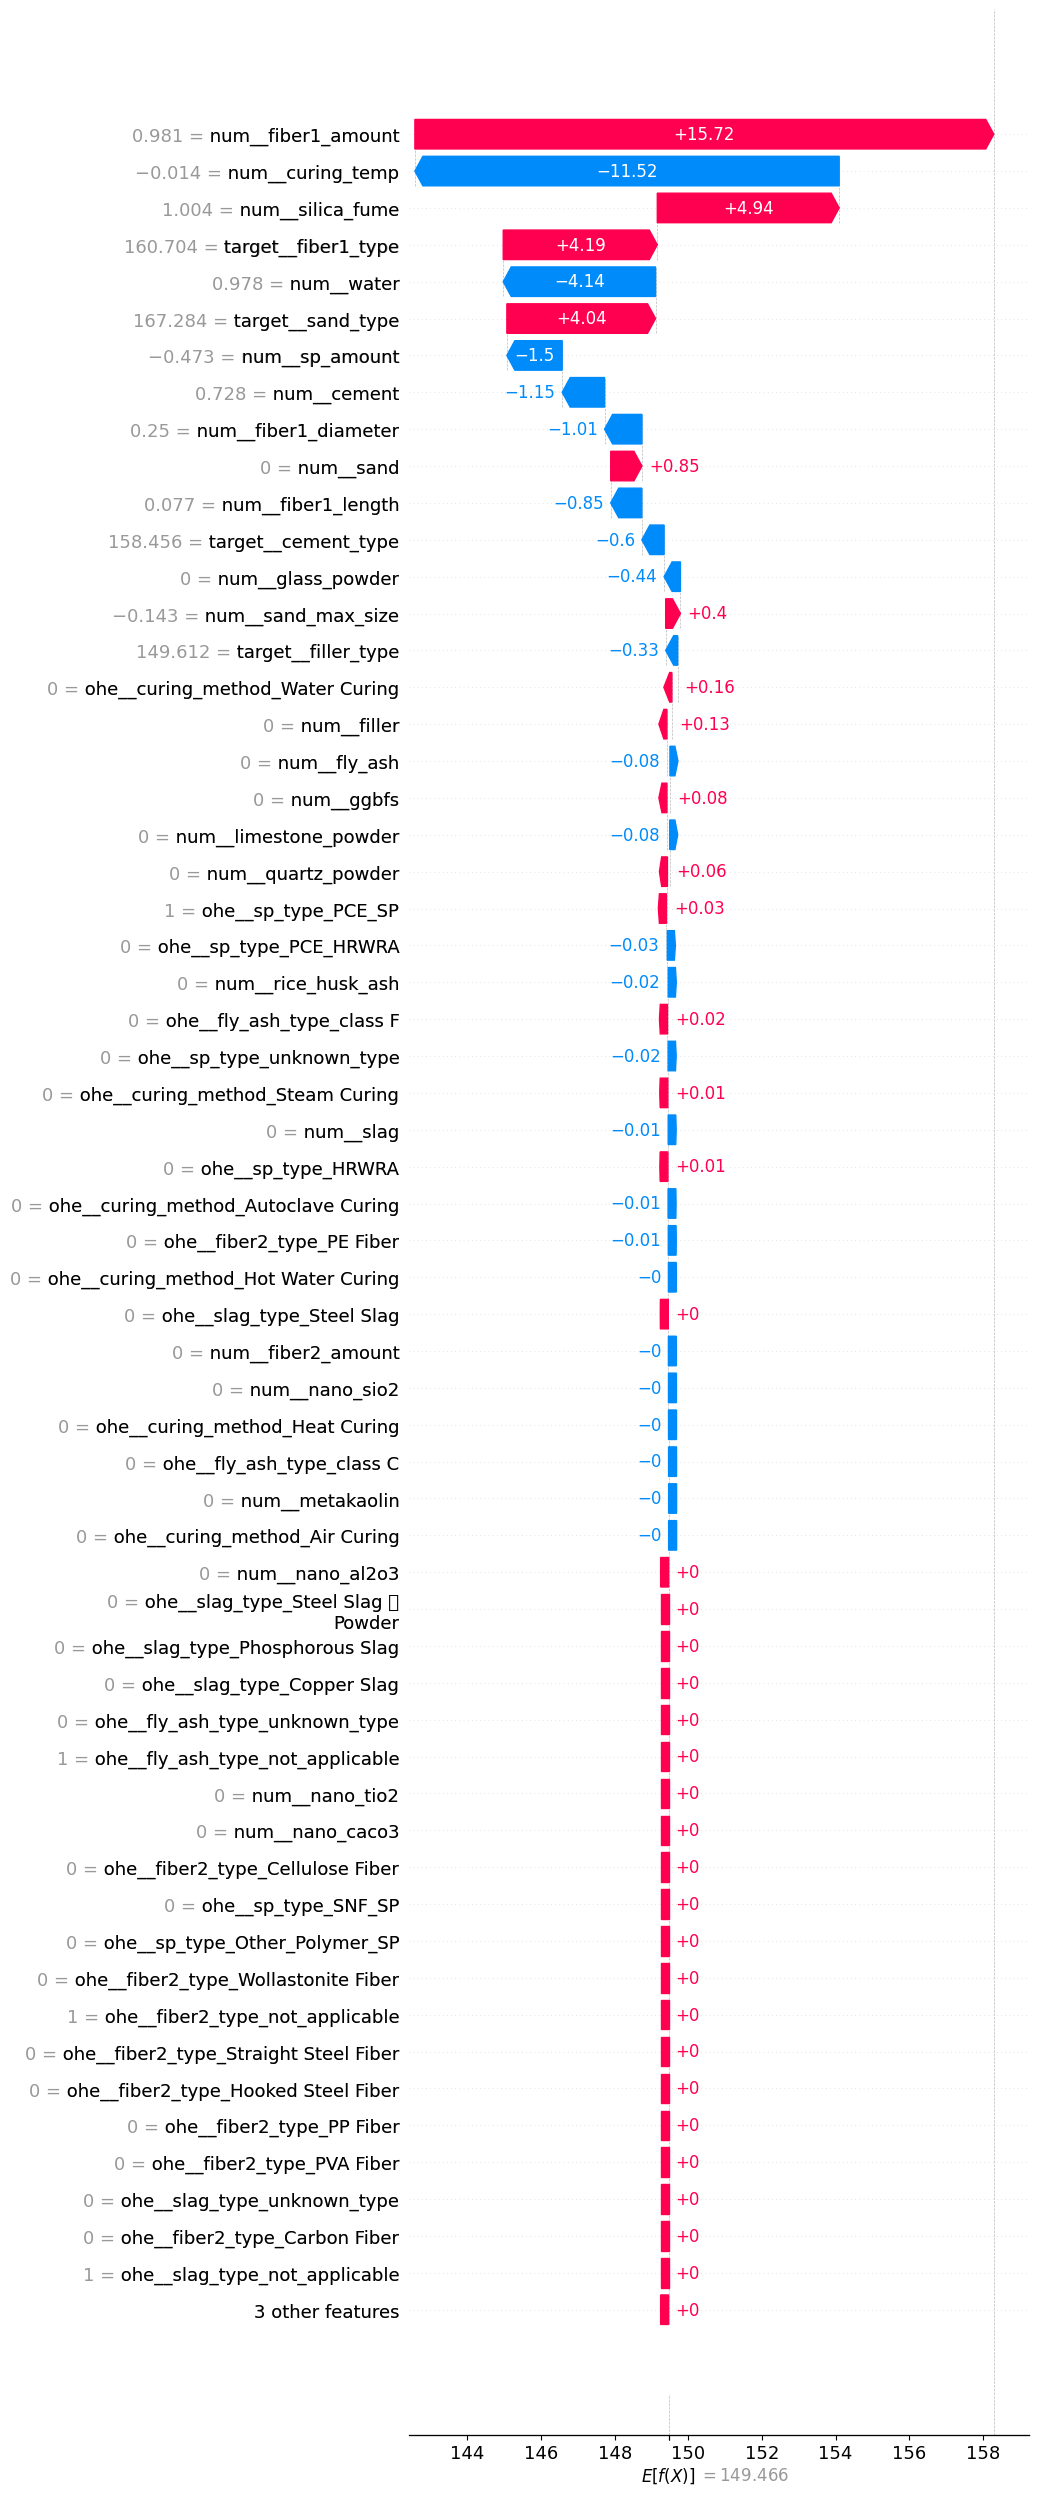

In [13]:
import shap

# Isolate the worst-performing publication
target_pub = 'Ref-85-Research'
test_mask = groups == target_pub
train_mask = groups != target_pub

X_train_shap = X[train_mask]
Y_train_shap = Y[train_mask]
X_test_shap = X[test_mask]
Y_test_shap = Y[test_mask]

# Fit the best XGBoost pipeline on this LOPO split
pipe_shap = best_pipelines['XGBoost']
pipe_shap.fit(X_train_shap, Y_train_shap)

# Extract the preprocessor and the actual XGBoost model
preprocessor = pipe_shap.named_steps['preprocessor']
xgb_model = pipe_shap.named_steps['model']

# Transform the test data so SHAP can read the encoded and scaled features
X_test_transformed = preprocessor.transform(X_test_shap)
feature_names = preprocessor.get_feature_names_out()

# Calculate Errors to find the absolute worst prediction
Y_pred_shap = pipe_shap.predict(X_test_shap)
errors = np.abs(Y_test_shap.values - Y_pred_shap)
worst_idx = np.argmax(errors) # Index of the row with the biggest mistake

print(f"SHAP Analysis for the max error publication {target_pub}")
print(f"True Concrete Strength:      {Y_test_shap.values[worst_idx]:.2f} MPa")
print(f"XGBoost Predicted Strength:  {Y_pred_shap[worst_idx]:.2f} MPa")
print(f"Absolute Error:              {errors[worst_idx]:.2f} MPa")

# Initialize SHAP Explainer and calculate values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_transformed)
shap_values.feature_names = feature_names

# Plot the Waterfall chart for the worst prediction
plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_values[worst_idx], max_display=60, show=False)
ax = plt.gca()
ax.tick_params(axis='x', top=False, labeltop=False)
plt.show()

# E[f(X)] is the average prediction 